In [28]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from compartments import (
    SEIR_patch_get_trajectory,
    CompartmentPatchArray,
    combine_mobility_agerates,
    get_patch_based_betas_from_unit_betas
)

In [29]:
CASES_FILENAME = 'karnataka-data/IRDD_allka.csv'
CASESDATAFRAME = pd.read_csv(CASES_FILENAME)
KAGEOJSON = 'karnataka-data/karnataka_districts.geojson'
KAMAP = gpd.read_file(KAGEOJSON)

In [30]:
CASESDATAFRAME.head()

,Date,District,Infected,Recovered,Deceased
0,22-03-2020,Bagalakote,0,0,0
1,23-03-2020,Bagalakote,0,0,0
2,24-03-2020,Bagalakote,0,0,0
3,25-03-2020,Bagalakote,0,0,0
4,26-03-2020,Bagalakote,0,0,0


In [31]:
CASESDATAFRAME['Date'] = pd.to_datetime(CASESDATAFRAME['Date'])

/var/folders/00/fvdyb_yx0lg2wtdhb1m8jlvm0000gn/T/ipykernel_32252/1126225949.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  CASESDATAFRAME['Date'] = pd.to_datetime(CASESDATAFRAME['Date'])


In [32]:
DISTRICTS_UNITS = CASESDATAFRAME['District'].unique()
DISTRICTS_UNITS = list(DISTRICTS_UNITS)
print(f'Number of Districts: {len(DISTRICTS_UNITS)}')

Number of Districts: 32


In [33]:
KAMAP_DISTRICTS = list(KAMAP['name'].unique())
len(KAMAP_DISTRICTS)
KAMAP_DISTRICTS = sorted(KAMAP_DISTRICTS)
# for i, dist in enumerate(KAMAP_DISTRICTS):
#     print(dist, DISTRICTS_UNITS[i])

In [34]:
CASESDATAFRAME.head()

,Date,District,Infected,Recovered,Deceased
0,2020-03-22,Bagalakote,0,0,0
1,2020-03-23,Bagalakote,0,0,0
2,2020-03-24,Bagalakote,0,0,0
3,2020-03-25,Bagalakote,0,0,0
4,2020-03-26,Bagalakote,0,0,0


## Calibirate the contact rates for the first wave before the vaccination

In [35]:
CASESDATAFRAME[CASESDATAFRAME['District']=='Bagalakote']

,Date,District,Infected,Recovered,Deceased
0,2020-03-22,Bagalakote,0,0,0
1,2020-03-23,Bagalakote,0,0,0
2,2020-03-24,Bagalakote,0,0,0
3,2020-03-25,Bagalakote,0,0,0
4,2020-03-26,Bagalakote,0,0,0
...,...,...,...,...,...
1038,2023-01-28,Bagalakote,0,0,0
1039,2023-01-29,Bagalakote,0,0,0
1040,2023-01-30,Bagalakote,0,0,0
1041,2023-01-31,Bagalakote,0,0,0


In [36]:
def get_district_cases(
        dataframe,
        district:str,
        init_date:str,
        end_date:str,
        compartment_name:str
        ):
    district_cases = CASESDATAFRAME[CASESDATAFRAME['District']==district]
    district_test_cases = district_cases[district_cases['Date']>=init_date]
    district_test_cases = district_test_cases[district_test_cases['Date']<end_date]
    district_cases_confirmed = np.array(district_test_cases[compartment_name])
    return district_cases_confirmed

In [37]:
test_date_init = '2020-10-11'
test_date_end = '2020-10-31'

validation_date_init = '11-10-2020'
validation_date_end = '31-10-2020'


case_per_spatial_unit_test = list()
case_per_spatial_unit_validation = list()

for district in DISTRICTS_UNITS:
    # print(district, type(district), district=='Bagalakote')
    test_cases_array = get_district_cases(
        CASESDATAFRAME,
        district = district,
        init_date=test_date_init,
        end_date= test_date_end,
        compartment_name='Infected'
        )
    
    validation_cases_array = get_district_cases(
        CASESDATAFRAME,
        district = district,
        init_date=validation_date_init,
        end_date= validation_date_end,
        compartment_name='Infected'
        )
    case_per_spatial_unit_test.append(test_cases_array)
    case_per_spatial_unit_validation.append(validation_cases_array)

## LOADING THE AGE RATE MATRIX

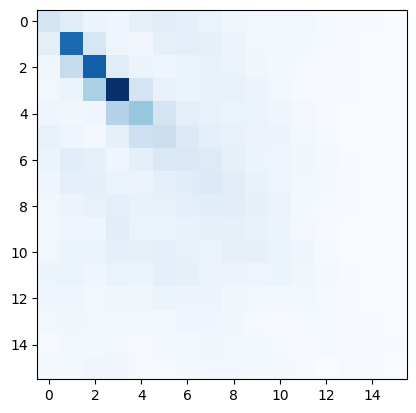

In [38]:
AGE_RATE_FILENAME = 'karnataka-data/ageinteractionmat.csv'
age_rate_matrix =np.loadtxt(AGE_RATE_FILENAME)
DELTA = 5
AGE_STRATIFICATION = [i*DELTA for i in range(age_rate_matrix.shape[0])]
plt.imshow(age_rate_matrix, cmap='Blues')
plt.show()

## Defining a mobility matrix

In [39]:
MOBILITY = np.eye(len(DISTRICTS_UNITS))

In [ ]:
# Combine to form a new network matrix
